Mounted at /content/drive
Total classes found: 20
Classes: ['Apple_Apple_Rust', 'Apple_Apple_Scab', 'Apple_Black_Rot', 'Apple_Healthy', 'CASAVA_0CBB', 'CASAVA_1CBSD', 'CASAVA_2CGM', 'CASAVA_3CMD', 'CASAVA_4CHL', 'Corn_Common_Rust', 'Corn_Gray_Leaf_Spot', 'Corn_Healthy', 'Corn_Northern_Leaf_Blight', 'Grape_Black_Measles', 'Grape_Black_Rot', 'Grape_Healthy', 'Grape_Leaf_blight', 'Potato_Early_blight', 'Potato_Healthy', 'Potato_Late_Blight']
Loaded Apple: Train=2218, Val=316, Test=637
Loaded CASAVA: Train=1750, Val=250, Test=500
Loaded Corn: Train=2695, Val=384, Test=773
Loaded Grape: Train=2843, Val=405, Test=814
Loaded Potato: Train=1506, Val=215, Test=431

Final dataset sizes:
Train: 11012
Validation: 1570
Test: 3155


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=Inception_V3_Weights.IMAGENET1K_V1`. You can also use `weights=Inception_V3_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth
100%|██████████| 104M/104M [00:00<00:00, 122MB/s] 


Using device: cuda
Model has 20 output classes
Epoch 1/30 => Train Loss: 1.6673, Train Accuracy: 0.6339 | Validation Loss: 0.5739, Validation Accuracy: 0.8497
Epoch 2/30 => Train Loss: 0.9624, Train Accuracy: 0.7610 | Validation Loss: 0.4254, Validation Accuracy: 0.8650
Epoch 3/30 => Train Loss: 0.8721, Train Accuracy: 0.7760 | Validation Loss: 0.3999, Validation Accuracy: 0.8675
Epoch 4/30 => Train Loss: 0.8133, Train Accuracy: 0.7821 | Validation Loss: 0.3570, Validation Accuracy: 0.8790
Epoch 5/30 => Train Loss: 0.7796, Train Accuracy: 0.7885 | Validation Loss: 0.3156, Validation Accuracy: 0.8962
Epoch 6/30 => Train Loss: 0.7646, Train Accuracy: 0.7948 | Validation Loss: 0.3205, Validation Accuracy: 0.8885
Epoch 7/30 => Train Loss: 0.7705, Train Accuracy: 0.7882 | Validation Loss: 0.3292, Validation Accuracy: 0.8847
Epoch 8/30 => Train Loss: 0.7269, Train Accuracy: 0.8034 | Validation Loss: 0.3018, Validation Accuracy: 0.9019
Epoch 9/30 => Train Loss: 0.7465, Train Accuracy: 0.7995 

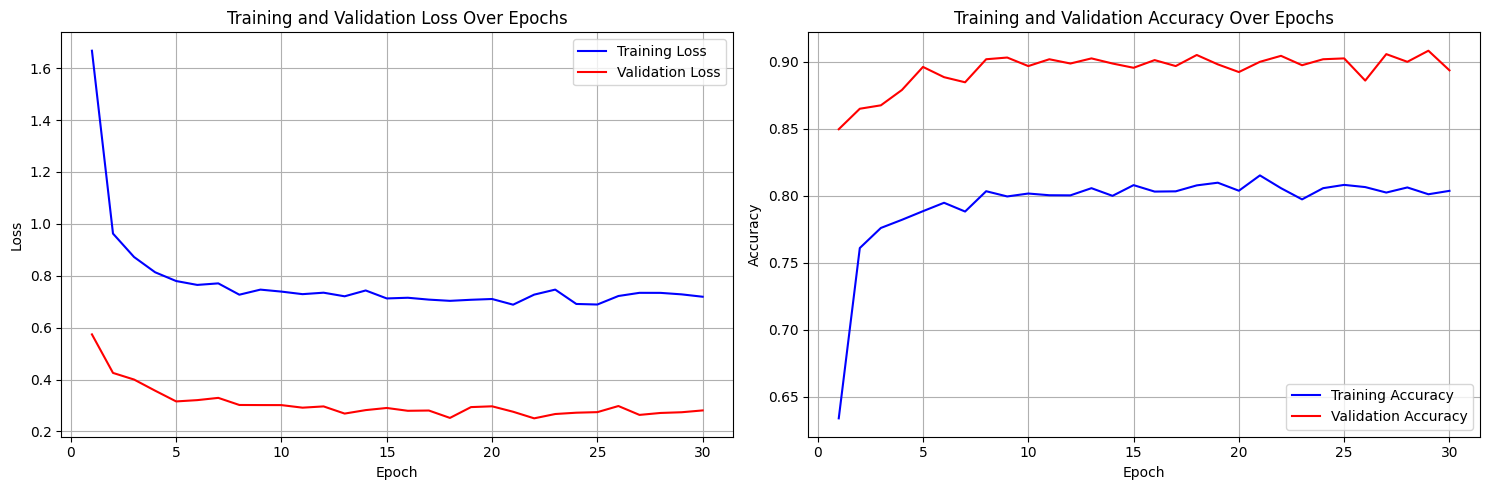


DETAILED SUBCLASS CLASSIFICATION RESULTS (WITH INDIVIDUAL ACCURACY)

APPLE:
--------------------------------------------------------------------------------
Rust                      | Accuracy: 82.14% | Precision: 100.00% | Recall: 82.14% | F1-Score: 90.20% | Support: 56.0
Scab                      | Accuracy: 79.37% | Precision: 90.91% | Recall: 79.37% | F1-Score: 84.75% | Support: 126.0
Black_Rot                 | Accuracy: 98.40% | Precision: 96.85% | Recall: 98.40% | F1-Score: 97.62% | Support: 125.0
Healthy                   | Accuracy: 100.00% | Precision: 92.44% | Recall: 100.00% | F1-Score: 96.07% | Support: 330.0

CASAVA:
--------------------------------------------------------------------------------
0CBB                      | Accuracy: 72.00% | Precision: 85.71% | Recall: 72.00% | F1-Score: 78.26% | Support: 100.0
1CBSD                     | Accuracy: 74.00% | Precision: 57.81% | Recall: 74.00% | F1-Score: 64.91% | Support: 100.0
2CGM                      | Accuracy: 46.0

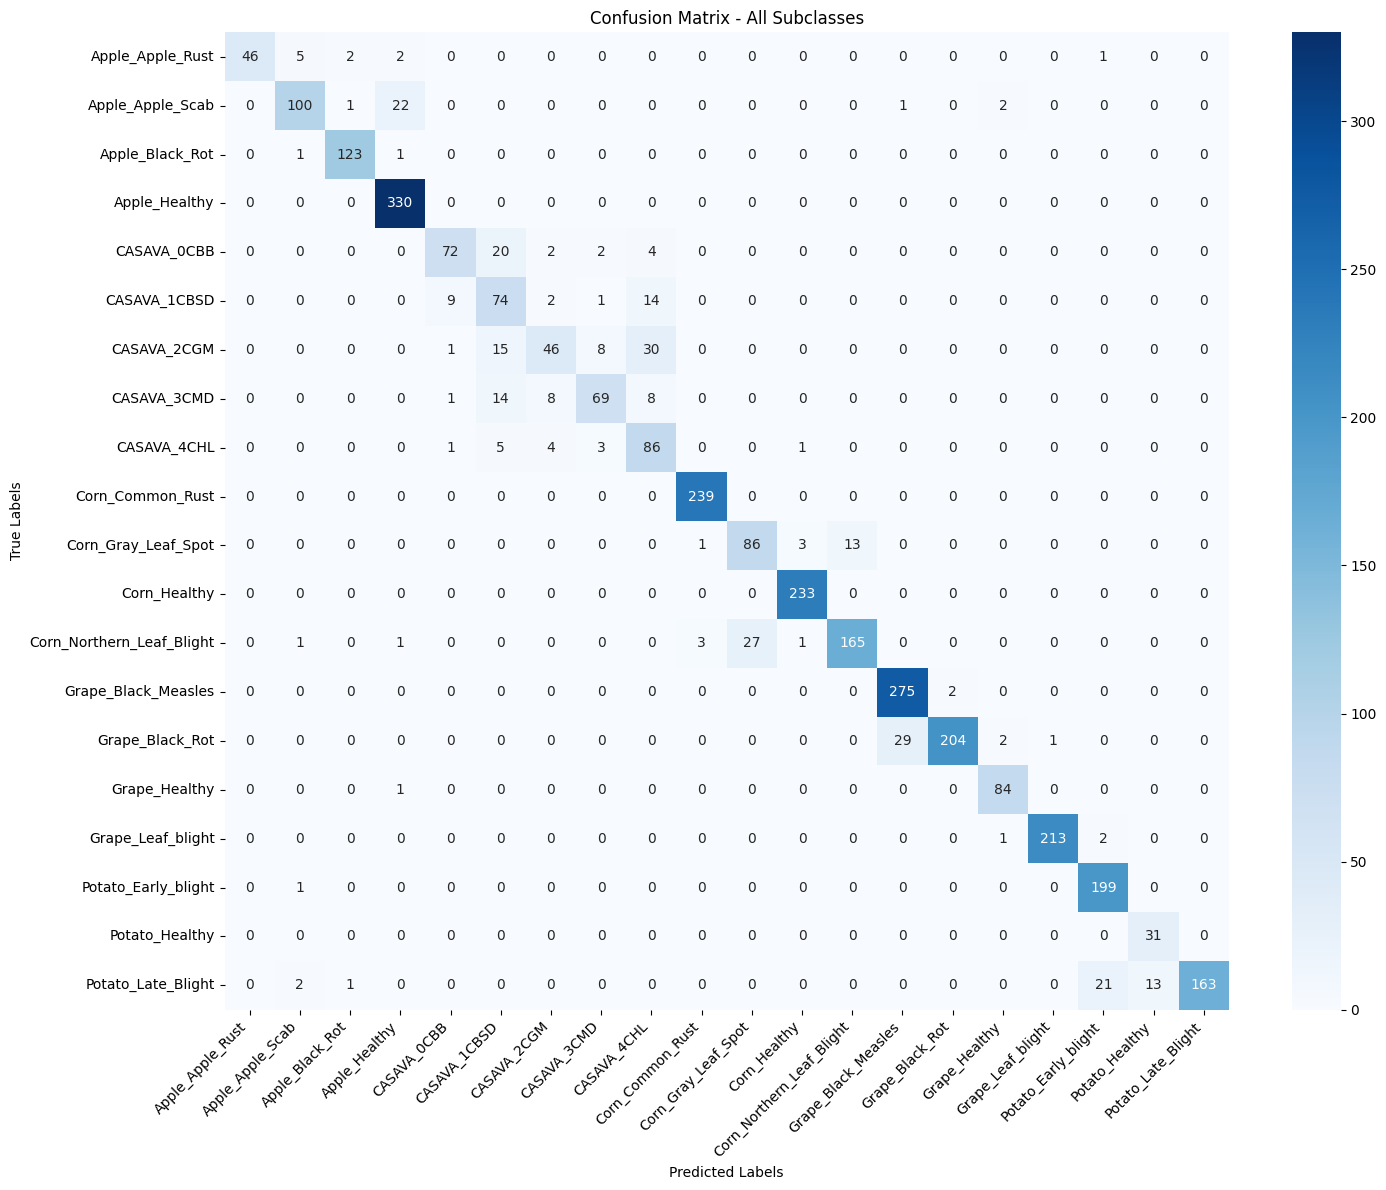

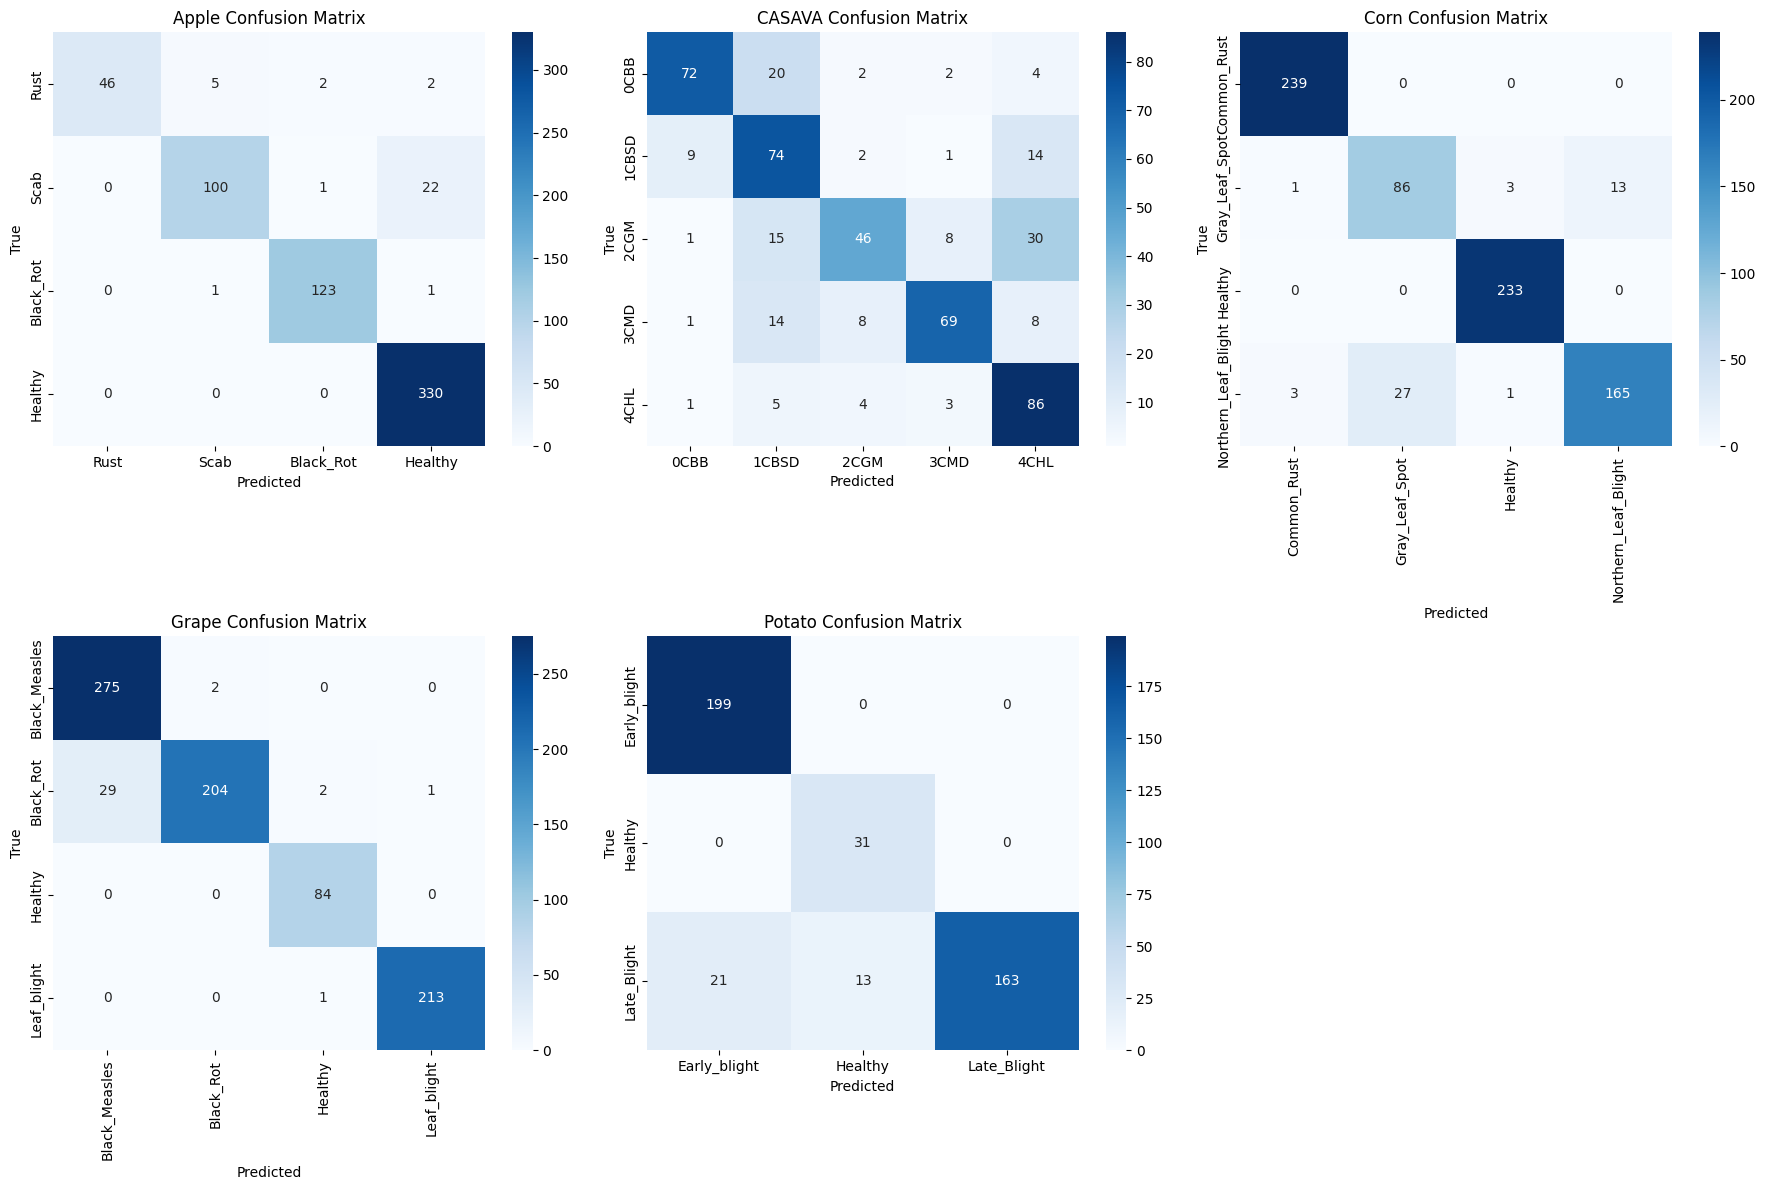

In [ ]:
# Cell 1: Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Cell 2: Extract Dataset
import zipfile
import os

zip_path = '/content/drive/My Drive/DataSet.zip'
output_dir = '/content/dataset/'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(output_dir)

# Cell 3: Import Required Libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, ConcatDataset
from torchvision import datasets, transforms, models
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Cell 4: Define Data Transformations for Inception v3 (299x299 input)
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(299),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]),
    'val': transforms.Compose([
        transforms.Resize(342),  # Specific size for Inception v3
        transforms.CenterCrop(299),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]),
    'test': transforms.Compose([
        transforms.Resize(342),
        transforms.CenterCrop(299),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]),
}

# Cell 5: Load Datasets with Proper Splits (Same as before)
dataset_base_path = '/content/dataset/DataSet'
species_folders = ['Apple', 'CASAVA', 'Corn', 'Grape', 'Potato']

# Initialize lists to store datasets
train_datasets = []
val_datasets = []
test_datasets = []

# Create a mapping for class names to indices
all_classes = []
class_to_species = {}
global_class_idx = 0

# First pass: collect all class names and create mapping
for species in species_folders:
    species_path = os.path.join(dataset_base_path, species)
    train_dir = os.path.join(species_path, 'Train')

    if os.path.exists(train_dir):
        temp_dataset = datasets.ImageFolder(train_dir)
        for class_name in temp_dataset.classes:
            full_class_name = f"{species}_{class_name}"
            all_classes.append(full_class_name)
            class_to_species[full_class_name] = species
            global_class_idx += 1

print(f"Total classes found: {len(all_classes)}")
print("Classes:", all_classes)

# Second pass: load datasets with proper class mapping
for species in species_folders:
    species_path = os.path.join(dataset_base_path, species)
    train_dir = os.path.join(species_path, 'Train')
    val_dir = os.path.join(species_path, 'Validate')
    test_dir = os.path.join(species_path, 'Test')

    if all(os.path.exists(d) for d in [train_dir, val_dir, test_dir]):
        # Load datasets
        train_dataset = datasets.ImageFolder(train_dir, transform=data_transforms['train'])
        val_dataset = datasets.ImageFolder(val_dir, transform=data_transforms['val'])
        test_dataset = datasets.ImageFolder(test_dir, transform=data_transforms['test'])

        # Remap class indices to global indices
        species_to_global_mapping = {}
        for local_idx, class_name in enumerate(train_dataset.classes):
            full_class_name = f"{species}_{class_name}"
            global_idx = all_classes.index(full_class_name)
            species_to_global_mapping[local_idx] = global_idx

        # Create custom datasets with remapped labels
        class RemappedDataset(torch.utils.data.Dataset):
            def __init__(self, original_dataset, label_mapping):
                self.original_dataset = original_dataset
                self.label_mapping = label_mapping

            def __len__(self):
                return len(self.original_dataset)

            def __getitem__(self, idx):
                image, label = self.original_dataset[idx]
                new_label = self.label_mapping[label]
                return image, new_label

        # Create remapped datasets
        train_remapped = RemappedDataset(train_dataset, species_to_global_mapping)
        val_remapped = RemappedDataset(val_dataset, species_to_global_mapping)
        test_remapped = RemappedDataset(test_dataset, species_to_global_mapping)

        train_datasets.append(train_remapped)
        val_datasets.append(val_remapped)
        test_datasets.append(test_remapped)

        print(f"Loaded {species}: Train={len(train_dataset)}, Val={len(val_dataset)}, Test={len(test_dataset)}")

# Combine all datasets
combined_train = ConcatDataset(train_datasets)
combined_val = ConcatDataset(val_datasets)
combined_test = ConcatDataset(test_datasets)

# Create DataLoaders
train_loader = DataLoader(combined_train, batch_size=32, shuffle=True)
val_loader = DataLoader(combined_val, batch_size=32, shuffle=False)
test_loader = DataLoader(combined_test, batch_size=32, shuffle=False)

print(f"\nFinal dataset sizes:")
print(f"Train: {len(combined_train)}")
print(f"Validation: {len(combined_val)}")
print(f"Test: {len(combined_test)}")

# Cell 6: Define Inception v3 Model
model = models.inception_v3(pretrained=True)

# Freeze all layers
for param in model.parameters():
    param.requires_grad = False

# Modify the final layer and auxiliary classifier
num_classes = len(all_classes)
model.fc = nn.Linear(model.fc.in_features, num_classes)
model.AuxLogits.fc = nn.Linear(model.AuxLogits.fc.in_features, num_classes)

# Move to device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
print(f"Using device: {device}")
print(f"Model has {num_classes} output classes")

# Cell 7: Training Loop with Loss/Accuracy Tracking (Modified for Inception v3)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001)

num_epochs = 30

# Lists to store training history for plotting
train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

for epoch in range(num_epochs):
    # Training phase
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()

        # Inception v3 returns both main and auxiliary outputs during training
        outputs, aux_outputs = model(inputs)

        # Calculate both losses with weight 0.4 for auxiliary loss
        loss1 = criterion(outputs, labels)
        loss2 = criterion(aux_outputs, labels)
        loss = loss1 + 0.4 * loss2

        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader)
    epoch_accuracy = correct / total

    # Validation phase
    model.eval()
    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)  # Only main output during evaluation
            loss = criterion(outputs, labels)
            val_running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss = val_running_loss / len(val_loader)
    val_accuracy = val_correct / val_total

    # Store values for plotting
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_accuracy)
    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)

    print(f"Epoch {epoch+1}/{num_epochs} => "
          f"Train Loss: {epoch_loss:.4f}, Train Accuracy: {epoch_accuracy:.4f} | "
          f"Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_accuracy:.4f}")

# Plot Training History
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot Loss
ax1.plot(range(1, num_epochs + 1), train_losses, 'b-', label='Training Loss')
ax1.plot(range(1, num_epochs + 1), val_losses, 'r-', label='Validation Loss')
ax1.set_title('Training and Validation Loss Over Epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

# Plot Accuracy
ax2.plot(range(1, num_epochs + 1), train_accuracies, 'b-', label='Training Accuracy')
ax2.plot(range(1, num_epochs + 1), val_accuracies, 'r-', label='Validation Accuracy')
ax2.set_title('Training and Validation Accuracy Over Epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

# Cell 8: Testing and Detailed Metrics (Same as before)
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)  # Only main output
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Generate classification report
report = classification_report(all_labels, all_preds, target_names=all_classes, output_dict=True)

# Calculate individual class accuracies
def calculate_class_accuracy(y_true, y_pred, class_idx):
    """Calculate accuracy for a specific class"""
    class_mask = (np.array(y_true) == class_idx)
    if np.sum(class_mask) == 0:
        return 0.0
    class_predictions = np.array(y_pred)[class_mask]
    class_true = np.array(y_true)[class_mask]
    return np.sum(class_predictions == class_true) / len(class_true)

# Create detailed results table with accuracy
results_data = []
for i, class_name in enumerate(all_classes):
    if class_name in report:
        species = class_to_species[class_name]
        subclass = class_name.replace(f"{species}_", "")

        precision = report[class_name]['precision'] * 100
        recall = report[class_name]['recall'] * 100
        f1_score = report[class_name]['f1-score'] * 100
        support = report[class_name]['support']

        # Calculate individual class accuracy
        class_accuracy = calculate_class_accuracy(all_labels, all_preds, i) * 100

        results_data.append({
            'Species': species,
            'Subclass': subclass,
            'Accuracy (%)': f"{class_accuracy:.2f}",
            'Precision (%)': f"{precision:.2f}",
            'Recall (%)': f"{recall:.2f}",
            'F1-Score (%)': f"{f1_score:.2f}",
            'Support': support
        })

# Create DataFrame and display results
results_df = pd.DataFrame(results_data)

print("\n" + "="*90)
print("DETAILED SUBCLASS CLASSIFICATION RESULTS (WITH INDIVIDUAL ACCURACY)")
print("="*90)

# Group by species and display
for species in species_folders:
    species_data = results_df[results_df['Species'] == species]
    if not species_data.empty:
        print(f"\n{species.upper()}:")
        print("-" * 80)
        for _, row in species_data.iterrows():
            print(f"{row['Subclass']:<25} | Accuracy: {row['Accuracy (%)']}% | "
                  f"Precision: {row['Precision (%)']}% | Recall: {row['Recall (%)']}% | "
                  f"F1-Score: {row['F1-Score (%)']}% | Support: {row['Support']}")

# Overall accuracy
overall_accuracy = report['accuracy'] * 100
print(f"\nOVERALL ACCURACY: {overall_accuracy:.2f}%")

# Create a summary table
print("\n" + "="*90)
print("SUMMARY TABLE")
print("="*90)
print(f"{'Species':<12} {'Subclass':<25} {'Accuracy':<10} {'Precision':<10} {'Recall':<10} {'F1-Score':<10} {'Support':<8}")
print("-" * 90)
for _, row in results_df.iterrows():
    print(f"{row['Species']:<12} {row['Subclass']:<25} {row['Accuracy (%)']:<10} "
          f"{row['Precision (%)']:<10} {row['Recall (%)']:<10} {row['F1-Score (%)']:<10} {row['Support']:<8}")

# Print traditional classification report
print("\n" + "="*90)
print("TRADITIONAL CLASSIFICATION REPORT")
print("="*90)
print(classification_report(all_labels, all_preds, target_names=all_classes))

# Cell 9: Confusion Matrix (Same as before)
plt.figure(figsize=(15, 12))
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=all_classes, yticklabels=all_classes)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix - All Subclasses')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Cell 10: Species-wise Confusion Matrices (Same as before)
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, species in enumerate(species_folders):
    if idx < len(axes):
        # Get indices for this species
        species_classes = [i for i, cls in enumerate(all_classes) if cls.startswith(species)]

        if species_classes:
            # Extract submatrix for this species
            species_cm = cm[np.ix_(species_classes, species_classes)]
            species_labels = [all_classes[i].replace(f"{species}_", "") for i in species_classes]

            sns.heatmap(species_cm, annot=True, fmt='d', cmap='Blues',
                       xticklabels=species_labels, yticklabels=species_labels,
                       ax=axes[idx])
            axes[idx].set_title(f'{species} Confusion Matrix')
            axes[idx].set_xlabel('Predicted')
            axes[idx].set_ylabel('True')

# Hide unused subplot
if len(species_folders) < len(axes):
    axes[-1].set_visible(False)

plt.tight_layout()
plt.show()